# ASL Vision - Model Training
Transfer learning with MobileNetV2 for ASL letters and digits.


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models

/Users/saadbeg/Documents/GitHub/ASL-Vision/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
DATASET_PATH = "../data/raw/asl_dataset"

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

## Dataset Loading


In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 2515 files belonging to 36 classes.
Using 2012 files for training.


In [4]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 2515 files belonging to 36 classes.
Using 503 files for validation.


In [5]:
class_names = train_dataset.class_names

NUM_CLASSES = len(class_names)

print(class_names)

print("Number of classes:", NUM_CLASSES)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of classes: 36


In [6]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.RandomBrightness(0.1)

])

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

## Model Definition


In [8]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224, 224, 3),

    include_top=False,

    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
base_model.trainable = False

In [10]:
model = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(NUM_CLASSES, activation="softmax")

])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training


In [12]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [13]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 522ms/step - accuracy: 0.1489 - loss: 3.2298 - val_accuracy: 0.4791 - val_loss: 1.8466
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 489ms/step - accuracy: 0.5028 - loss: 1.7659 - val_accuracy: 0.6620 - val_loss: 1.2886
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 550ms/step - accuracy: 0.6603 - loss: 1.2828 - val_accuracy: 0.7336 - val_loss: 1.0018
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 740ms/step - accuracy: 0.7091 - loss: 1.0655 - val_accuracy: 0.7614 - val_loss: 0.8792
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 965ms/step - accuracy: 0.7628 - loss: 0.9065 - val_accuracy: 0.7952 - val_loss: 0.7554
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7897 - loss: 0.7794 - val_accuracy: 0.7913 - val_loss: 0.7003
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8240 - loss: 0.6846 - val_accuracy: 0.8171 - val_loss: 0.6275
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8435 - loss: 0.6116 - val_accuracy: 0.8

# MobileNetV2 Transfer Learning Training

## Model Architecture

This project uses:
- MobileNetV2
- transfer learning
- TensorFlow/Keras

instead of training a CNN from scratch.

### Why Transfer Learning?

The dataset contains approximately:
- 2500 total images
- 36 classes

Training a deep CNN from scratch on a relatively small dataset would likely:
- overfit quickly
- require significantly more data
- increase training time

MobileNetV2 was selected because it:
- is lightweight and efficient
- performs well on image classification tasks
- is optimized for real-time inference
- works well with smaller datasets

---

## Frozen Feature Extractor

The pretrained MobileNetV2 convolutional base was frozen during initial training.

This allows the model to:
- reuse pretrained visual features
- reduce overfitting
- train faster
- generalize better on limited data

Only the final classification layers were trained for ASL gesture classification.

---

## Data Augmentation

Data augmentation was applied during training to improve model robustness.

Applied augmentations:
- horizontal flipping
- small rotations
- zooming
- brightness adjustments

This helps simulate real-world webcam variability and improves generalization performance.

---

## Initial Training Results

The model demonstrated strong learning behavior during training:
- training accuracy steadily improved
- validation accuracy increased significantly
- loss decreased consistently

Validation accuracy exceeded 85% after only 10 epochs, indicating that:
- transfer learning was highly effective
- the dataset contains strong visual signal
- the preprocessing pipeline is functioning correctly

---

## Observations

Slight validation fluctuations near later epochs suggest mild overfitting may begin occurring as training progresses.

Potential future improvements include:
- fine-tuning MobileNetV2 layers
- additional augmentation strategies
- learning rate scheduling
- early stopping callbacks
- larger ASL datasets

In [14]:
acc = history.history["accuracy"]

val_acc = history.history["val_accuracy"]

loss = history.history["loss"]

val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

Text(0.5, 1.0, 'Training vs Validation Accuracy')

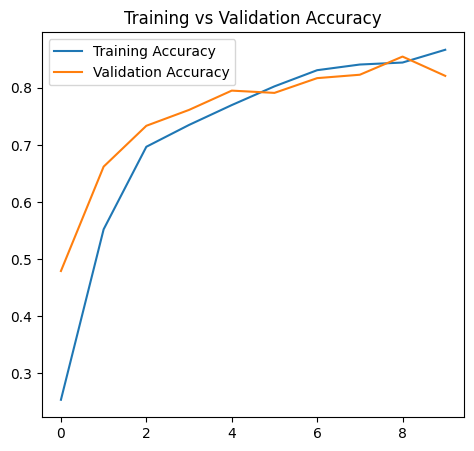

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(epochs_range, acc, label="Training Accuracy")

plt.plot(epochs_range, val_acc, label="Validation Accuracy")

plt.legend()

plt.title("Training vs Validation Accuracy")

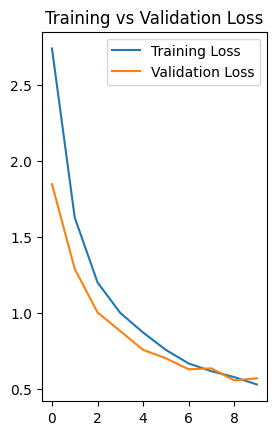

In [16]:
plt.subplot(1,2,2)

plt.plot(epochs_range, loss, label="Training Loss")

plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

In [17]:
model.save("../models/asl_mobilenetv2.keras")

## Evaluation


# Training Curve Analysis

## Accuracy Trends

Both training and validation accuracy improved consistently throughout training, indicating that the model successfully learned meaningful visual patterns from the ASL dataset.

Validation accuracy exceeded 85% after 10 epochs, demonstrating strong generalization performance despite the relatively small dataset size.

---

## Loss Trends

Training and validation loss steadily decreased during training, suggesting:
- stable optimization
- effective transfer learning
- successful preprocessing and augmentation

The close alignment between training and validation curves indicates minimal overfitting.

---

## Generalization Performance

The small gap between:
- training accuracy
- validation accuracy

suggests that:
- data augmentation was effective
- MobileNetV2 generalized well
- transfer learning significantly improved performance

---

## Observations

Slight fluctuations near later epochs suggest mild overfitting may begin occurring after extended training.

Potential future improvements include:
- early stopping callbacks
- fine-tuning pretrained layers
- larger datasets
- learning rate scheduling
- additional augmentation strategies

In [19]:
predictions = model.predict(validation_dataset)

16/16 ━━━━━━━━━━━━━━━━━━━━ 576s 34s/step


In [20]:
predicted_labels = tf.argmax(predictions, axis=1)

In [21]:
true_labels = tf.concat(
    [labels for images, labels in validation_dataset],
    axis=0
)

2026-05-19 13:56:29.765075: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

In [23]:
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

           0       0.05      0.08      0.06        13
           1       0.00      0.00      0.00        12
           2       0.00      0.00      0.00        17
           3       0.11      0.11      0.11         9
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00        15
           6       0.00      0.00      0.00         9
           7       0.04      0.08      0.05        13
           8       0.00      0.00      0.00        14
           9       0.00      0.00      0.00        17
           a       0.00      0.00      0.00        13
           b       0.05      0.07      0.06        15
           c       0.06      0.06      0.06        16
           d       0.00      0.00      0.00        13
           e       0.00      0.00      0.00        14
           f       0.06      0.06      0.06        16
           g       0.00      0.00      0.00        23
           h       0.00    

In [24]:
cm = confusion_matrix(true_labels, predicted_labels)

## Misclassification Review


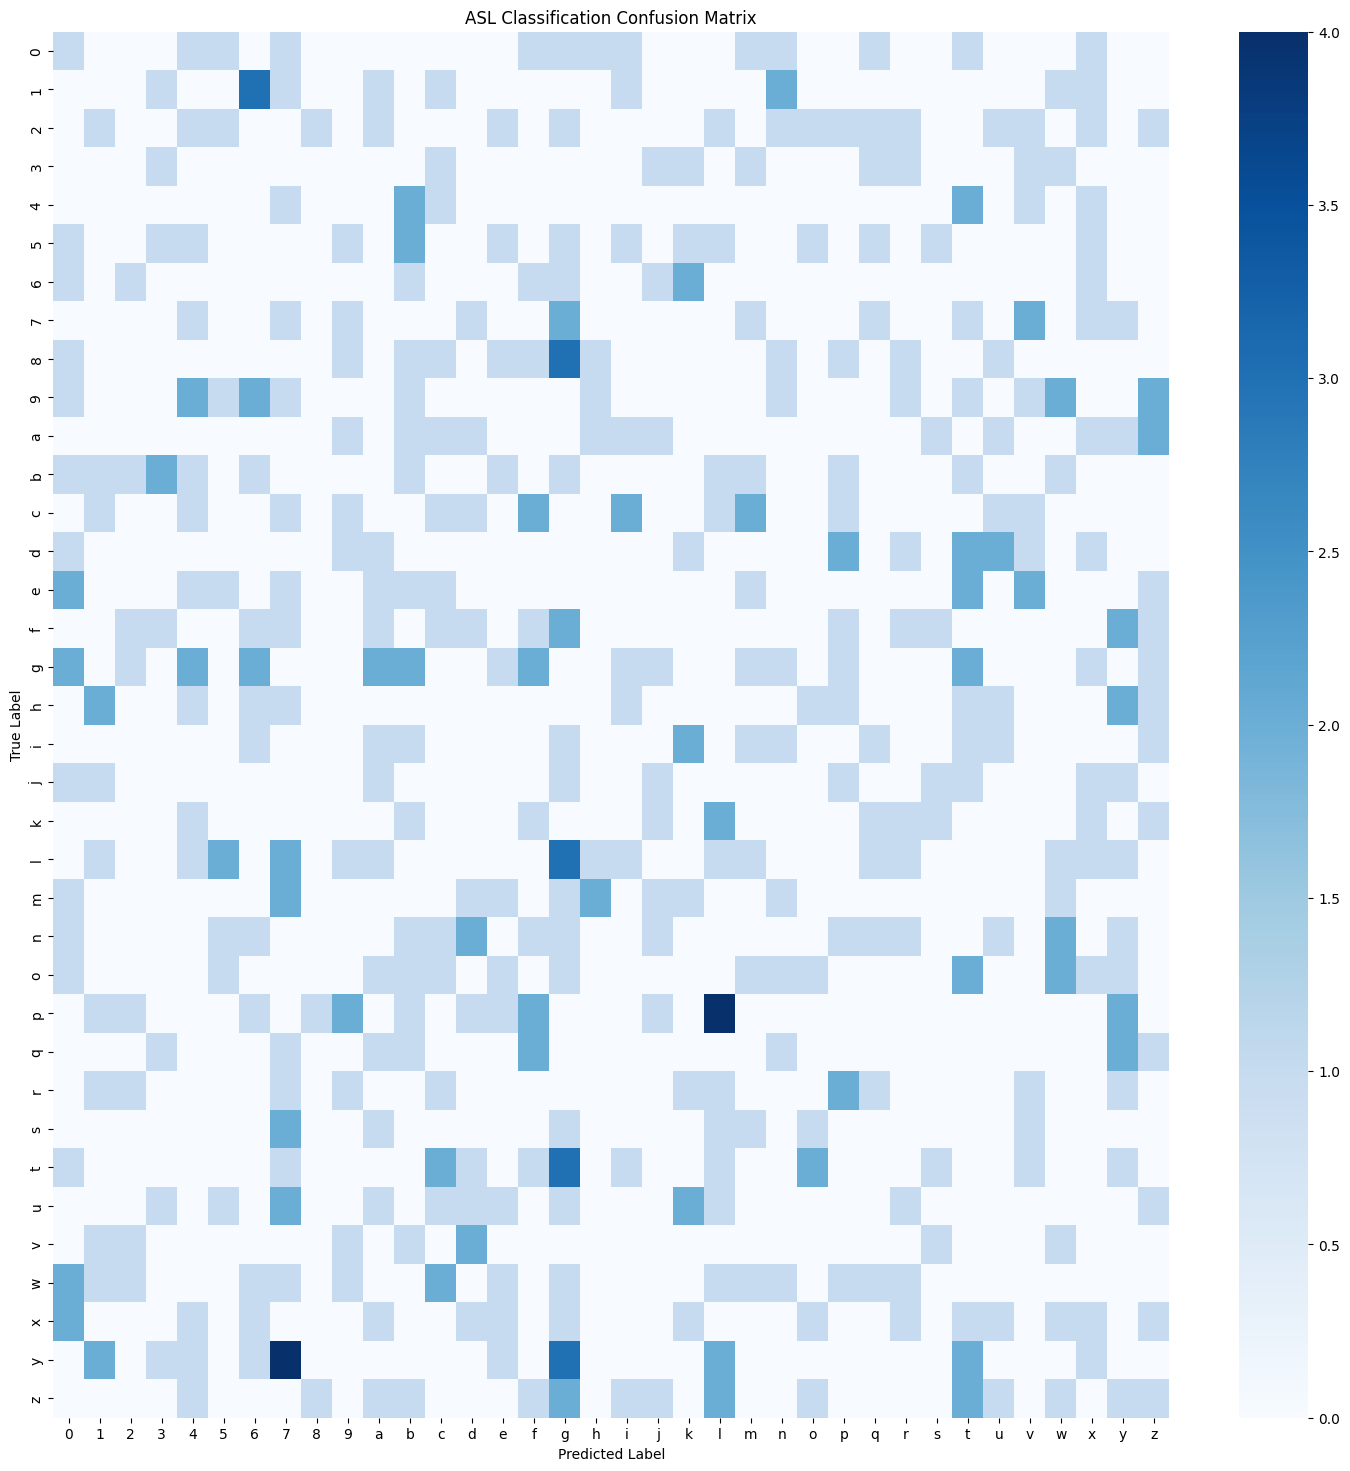

In [25]:
plt.figure(figsize=(18,18))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ASL Classification Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [26]:
misclassified_images = []

misclassified_true = []

misclassified_pred = []

In [ ]:
for images, labels in validation_dataset:

    preds = model.predict(images, verbose=0)

    pred_labels = tf.argmax(preds, axis=1, output_type=tf.int64)

    for i in range(len(labels)):

        if int(pred_labels[i]) != int(labels[i]):

            misclassified_images.append(images[i])

            misclassified_true.append(class_names[labels[i]])

            misclassified_pred.append(class_names[pred_labels[i]])

InvalidArgumentError: cannot compute NotEqual as input #1(zero-based) was expected to be a int64 tensor but is a int32 tensor [Op:NotEqual] name: 

In [ ]:
plt.figure(figsize=(15,15))

for i in range(min(9, len(misclassified_images))):

    ax = plt.subplot(3,3,i+1)

    plt.imshow(misclassified_images[i].numpy().astype("uint8"))

    plt.title(
        f"True: {misclassified_true[i]}\nPred: {misclassified_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()